# Python tutorial: Network inequity metrics — $\xi_a$ and $\xi_d$

This notebook introduces two closely related ways of measuring how
**inequitably** a resource is distributed across a social network.

## Why a network metric at all?

Existing measures implicitly assumed that all people are equal in their need for resource access, conflated network position with need, and did not explicitly allow researchers to define need in measures of resource access. Furthermore, the usual tools for measuring distributional unfairness — the Gini
coefficient, the Theil index — take a list of values and ask how unevenly
spread they are. They are blind to *who is next to whom*. Two populations
with identical Gini coefficients can be in completely different situations
once you know the social structure: in one, the people without the
resource sit next to people who have it; in the other, they are six hops
away from the nearest holder, on the periphery of the network.

For anything that travels through social ties — health information, a new
practice, a referral, a piece of advice — that difference is the whole
story. So the metrics here are built around a different primitive:

> **Access is not what you hold. Access is who you can reach that holds a resource.**

A node's access depends on how much resource exists *in its social network*,
discounted by how far away that resource sits. Inequity is then the
shortfall from full access, averaged across the population.

There is a second departure from Gini and Theil worth flagging early.
Those are *equality* measures: they treat all deviations from an even
split the same way. The metrics here are *equity* measures: they carry a
weight vector `w` that lets you say some people's shortfall matters more
than others' — typically because they need the resource more. With
uniform weights you get an equality-flavoured reading; with need-based
weights you get an equity reading. Most of this tutorial uses uniform
weights so that we can isolate the network mechanics, but `w` is where
the equity part of the metric actually lives.

## The two variants

Both metrics answer the same question and differ in exactly one respect:
**how access decays with distance.**

| | $\xi_a$ (attenuated) | $\xi_d$ (discrete) |
|---|---|---|
| Decay rule | smooth, exponential | hard boundary |
| Tuning parameter | `alpha` — decay rate | `d` — reach in hops |
| Access at distance *d* | `exp(-alpha * d)` — shrinks, never quite zero | 1 if *d* ≤ cutoff, else 0 |
| Reads `R` as | a continuous quantity | binary (holds it / doesn't) |
| Suits | resources that dilute with social distance (information, influence) | resources with a genuine catchment (an invitation, a referral) |

Neither is the "correct" one. They are two modelling commitments about
how far a resource travels, and picking between them is a substantive
claim about your case, not a technical detail.

## How this notebook is organised

1. The shared skeleton behind both metrics (notation and intuition)
2. The two definitions, in code, with a walk-through
3. A toy network small enough to check by hand
4. One resource vector, fed to both metrics
5. Reading the output, node by node
6. Sensitivity: what `alpha` and `d` actually do
7. Need weights: what `w` does, and why it is the equity part
8. Takeaways

Nothing here depends on data you don't have — the whole notebook runs on
a seven-node path graph you can verify with a pen.

## 0. The shared skeleton

Before any code, it helps to see that both metrics are the same two-step
construction with one interchangeable part.

**Step 1 — access.** For every node *i*, compute a score `A[i]` in [0, 1]
saying how well served that node is. This is where the two metrics differ.

*Attenuated version:* sum the resource held everywhere, each contribution
discounted by its distance from *i*.

$$A_i \;=\; \min\!\Big(1,\; \sum_j R_j \, e^{-\alpha\, d_{ij}}\Big)$$

Note that the sum includes *j = i* itself, where the distance is zero and
so the discount factor is `exp(0) = 1`. A node that holds the resource
counts its own holding in full — as it should.

*Discrete version:* check whether *i* is within `d` hops of anyone
holding the resource.

$$A_i \;=\; \begin{cases} 1 & \text{if } \min_{j:\,R_j > 0} d_{ij} \le \text{cutoff} \\ 0 & \text{otherwise} \end{cases}$$

**Step 2 — aggregate the shortfall.** Whatever access rule you used, the
inequity score is the weighted mean of what each node is *missing*:

$$\xi \;=\; \frac{\sum_i w_i\,(1 - A_i)}{\sum_i w_i}$$

So `1 - A[i]` is node *i*'s individual shortfall, and `w[i]` says how
heavily that shortfall should count. Both metrics land on the same scale:

- **ξ = 0** — perfect equity. Everyone the weights care about has full
  access.
- **ξ = 1** — maximal inequity. Nobody has any access (for example,
  nobody holds the resource at all).
- Values in between are the weighted average shortfall, and are
  interpretable as such: ξ = 0.6 means the average person — weighted by
  need — is missing 60% of the access they could have had.

Because it is a mean of per-node shortfalls rather than a summary of a
distribution's shape, ξ is decomposable: you can always ask *which* nodes
are driving the number by looking at the `A` dictionary the functions
return alongside it.

### Two implementation details worth knowing up front

- **Disconnected components.** $\xi_a$ builds its distance table with
  `nx.all_pairs_shortest_path_length`, which only lists nodes that are
  actually reachable. A node in a component with no resource in it gets
  `A = 0` and therefore a full shortfall of 1. That is the intended
  behaviour — unreachable is unreachable — but it means a fragmented
  network can push ξ up sharply, so it is worth checking connectivity
  before interpreting a high score.
- **The clip at 1.** With `normalize_A=True` (the default), access is
  capped at 1. Without the cap, a node sitting among several holders can
  score above 1 and end up with a *negative* shortfall, quietly
  subsidising other nodes' deficits in the average. Keeping the cap makes
  ξ a genuine average of shortfalls, each bounded in [0, 1].

In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, Optional, Tuple

## 1. The definitions

Both functions take the **same first two arguments**: a graph `G` and a
resource mapping `R: Dict[node, float]` with values in [0, 1] — how much
resource each node holds. They also share the weight dict `w`.

The one input the two treat differently is `R` itself. $\xi_a$ uses it as a
continuous quantity: a node holding 0.3 of the resource contributes 0.3,
discounted by distance. $\xi_d$ reads it as a flag: any node with
`R[node] > 0` is a holder, full stop, and 0.3 is treated no differently
from 1.0.

Feeding a single `R` to both is a deliberate choice. It means any
disagreement between the two numbers comes from the decay rule alone —
smooth taper versus hard cutoff — and not from having quietly handed them
different data.

Read the two function bodies side by side: the aggregation lines at the
bottom are identical, and only the block computing `A` changes.

In [16]:
def xi_a(G: nx.Graph,
         R: Dict[int, float],
         w: Optional[Dict[int, float]] = None,
         alpha: float = 1.0,
         normalize_A: bool = True) -> Tuple[float, Dict[int, float]]:
    """
    Attenuated network equity metric.

    R[j] is the (continuous) amount of resource node j holds. Node i's
    access A[i] is the sum, over all nodes j, of R[j] * exp(-alpha *
    d_ij) — resource held nearby contributes more, resource held far
    away contributes exponentially less, but never exactly zero. xi is
    the weighted mean of (1 - A[i]): 0 = perfect equity (everyone has
    full access), 1 = maximal inequity (no access anywhere).
    """
    nodes = list(G.nodes())
    if not nodes:
        return 1.0, {}

    if w is None:
        w = {node: 1.0 for node in nodes}

    dist = dict(nx.all_pairs_shortest_path_length(G))

    A = {}
    for i in nodes:
        access = sum(
            R.get(j, 0.0) * np.exp(-alpha * d)
            for j, d in dist[i].items()
        )
        A[i] = min(access, 1.0) if normalize_A else access

    total_weight = sum(w.values())
    if total_weight == 0:
        return 1.0, A

    xi = sum(w[i] * (1 - A[i]) for i in nodes) / total_weight
    return xi, A


def xi_d(G: nx.Graph,
         R: Dict[int, float],
         w: Optional[Dict[int, float]] = None,
         d: Optional[int] = None) -> Tuple[float, Dict[int, float]]:
    """
    Discrete network equity metric.

    R[j] > 0 marks node j as holding the resource (treat R as binary:
    0.0 or 1.0). Every other node is judged by binary reachability:
    A[i] = 1.0 if it lies within d hops of some resource holder,
    else A[i] = 0.0 (no partial credit for distance). xi is the
    weighted mean of (1 - A[i]): 0 = everyone is within cutoff of a
    holder, 1 = no one is (e.g. there are no holders at all).
    """
    nodes = list(G.nodes())
    if not nodes:
        return 1.0, {}

    if w is None:
        w = {node: 1.0 for node in nodes}

    total_weight = sum(w.values())
    if total_weight == 0:
        return 1.0, {}

    holders = [i for i, val in R.items() if val > 0]
    reachable: set = set()
    for h in holders:
        reachable.update(nx.single_source_shortest_path_length(G, h, cutoff=d))

    A = {i: (1.0 if i in reachable else 0.0) for i in nodes}

    xi = sum(w[i] * (1 - A[i]) for i in nodes) / total_weight
    return xi, A

### Walking through $\xi_a$

- `dist = dict(nx.all_pairs_shortest_path_length(G))` precomputes every
  pairwise hop count once. `dist[i]` is itself a dict, mapping each
  reachable *j* to the distance — nodes in other components simply do not
  appear as keys.
- The inner `sum` is the access formula. `R.get(j, 0.0)` is defensive: a
  node missing from `R` contributes nothing rather than raising. Note
  again that `dist[i]` contains `i` itself with distance 0, so a holder's
  own resource enters at full strength.
- `min(access, 1.0)` applies the cap discussed above.
- The final line is the weighted mean of `1 - A[i]`. The guard on
  `total_weight == 0` returns 1.0 — the maximally inequitable reading — on
  the grounds that a weighting scheme that cares about nobody cannot
  certify anything as equitable.
- The function returns **both** ξ and the per-node access dict, so you can
  always drill into the aggregate.

### Walking through $\xi_d$

- `holders` collects every node with a strictly positive entry in `R`.
- The loop over holders unions together the sets of nodes within `d`
  hops of each one — `single_source_shortest_path_length` with a `d`
  argument does the bounded search, and passing `d=None` means
  unbounded, i.e. the whole connected component.
- `A` is then a pure 0/1 indicator of membership in that reachable set.
  There is no partial credit: a node one hop past the boundary scores the
  same as a node that is twenty hops away.

## 2. A small toy network

A path graph of 7 nodes (0–6) makes the effect of distance easy to see by
eye. It is a chain: 0–1–2–3–4–5–6. Node 0 will hold the resource, and
because there is exactly one route between any two nodes, the distance
from node 0 to node *i* is simply *i*. That makes every number this
notebook prints checkable by hand.

Alongside the drawing we also keep the adjacency matrix `adj` — the same
graph as a plain 0/1 matrix. It isn't used by the metrics (they work off
the `networkx` object directly), but it is a useful sanity check that the
graph is what you think it is: you should see 1s only on the two
off-diagonals.

A path is of course an extreme topology — maximum diameter for its size,
no redundancy, every node a bottleneck. That is precisely why it is a good
first test: effects that are subtle in a realistic network are impossible
to miss here.

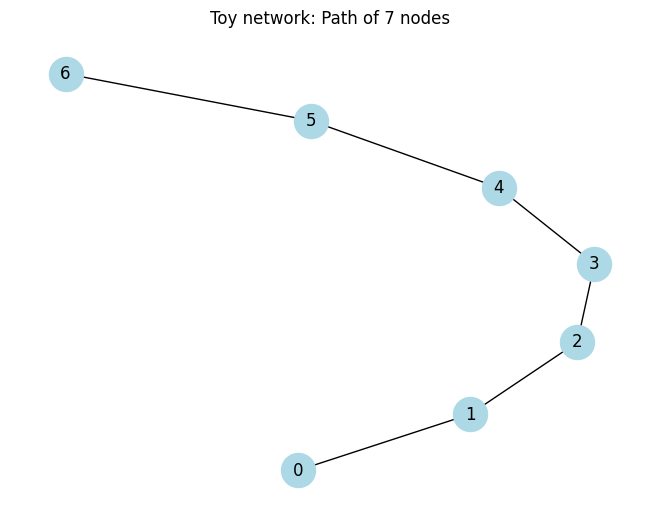

Adjacency matrix (G):
[[0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]]


In [17]:
G = nx.path_graph(7)  # nodes 0-6, edges (0,1),(1,2),...,(5,6)
adj = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))

nx.draw(G, with_labels=True, node_color="lightblue", node_size=600)
plt.title("Toy network: Path of 7 nodes")
plt.show()

print("Adjacency matrix (G):")
print(adj)

## 3. One resource vector, fed to both metrics

Node `0` — one end of the chain — holds the resource, and everyone else
has none. This is the worst-case placement on a path: it maximises the
average distance to the resource, so the ξ values that come out will be
high. Placing it at node 3 instead would halve the longest distance.

`w` gives equal priority weight to every node, so nothing in the
comparison below is driven by weighting choices. This is the *equality*
setting of the metric, and it is the right control for a tutorial about
the decay rules. In substantive use, `w` is where you would encode need —
larger weights on the people for whom lacking the resource matters most —
and the same network can then produce very different ξ values depending
on whether the high-need nodes sit near node 0 or out at node 6.

Note there is only **one** dict here — `R` — used directly by both $\xi_a$
and $\xi_d$.

In [18]:
R = {node: (1.0 if node == 0 else 0.0) for node in G.nodes()}
w = {node: 1.0 for node in G.nodes()}

print("R:", R)

R: {0: 1.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0}


Colouring the network by who holds the resource makes the setup visible.
Gold is the single holder; everything else is a node whose access has to
come through the chain.

(The layout uses `spring_layout`, so the path may not be drawn as a
straight line — the *drawing* is a cosmetic choice, while the distances
that matter are hop counts along the edges.)

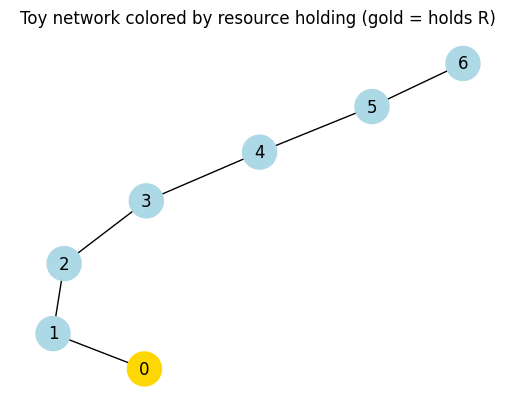

In [19]:
pos = nx.spring_layout(G, seed=0)
node_colors = ["gold" if R[n] > 0 else "lightblue" for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
plt.title("Toy network colored by resource holding (gold = holds R)")
plt.axis("off")
plt.show()

## 4. Compute both metrics on the same `R`

$\xi_a$ is called with `alpha=1.0`: each additional hop multiplies a
contribution by `exp(-1) ≈ 0.37`, so access falls by roughly two thirds
per step. $\xi_d$ is called with `cutoff=2`: everything within two hops of
node 0 is fully served, everything beyond is fully excluded.

Both return `(xi, A)`, so we can print the aggregate and then inspect the
per-node access scores that produced it. Comparing the two `A`
dictionaries is the fastest way to internalise what separates the metrics.

In [44]:
from IPython.display import display, Markdown

xi_a_val, A_a = xi_a(G, R, w=w, alpha=1.0)
xi_d_val, A_d = xi_d(G, R, w=w, d=2)

lines = [
    rf"$\xi_a$ ($\alpha$=1.0) = {xi_a_val:.3f}",
    rf"$\xi_d$ ($d$; cutoff=2) = {xi_d_val:.3f}",
    "",
    r"Per-node access under $\xi_a$ (A):",
]
lines += [f"- node {n}: A={a:.3f}" for n, a in A_a.items()]
lines += ["", r"Per-node access under $\xi_d$ (A):"]
lines += [f"- node {n}: A={a:.3f}" for n, a in A_d.items()]
display(Markdown("\n\n".join(lines)))

$\xi_a$ ($\alpha$=1.0) = 0.774

$\xi_d$ ($d$; cutoff=2) = 0.571



Per-node access under $\xi_a$ (A):

- node 0: A=1.000

- node 1: A=0.368

- node 2: A=0.135

- node 3: A=0.050

- node 4: A=0.018

- node 5: A=0.007

- node 6: A=0.002



Per-node access under $\xi_d$ (A):

- node 0: A=1.000

- node 1: A=1.000

- node 2: A=1.000

- node 3: A=0.000

- node 4: A=0.000

- node 5: A=0.000

- node 6: A=0.000

### Reading the output

**Under $\xi_a$,** the access column is just `exp(-1 * d)` evaluated along
the chain, because there is only one holder:

| node | distance from holder | `A` |
|---|---|---|
| 0 | 0 | 1.000 |
| 1 | 1 | 0.368 |
| 2 | 2 | 0.135 |
| 3 | 3 | 0.050 |
| 4 | 4 | 0.018 |
| 5 | 5 | 0.007 |
| 6 | 6 | 0.002 |

The shortfalls `1 - A` sum to about 5.42, and dividing by 7 gives
**$\xi_a$ ≈ 0.774**. Node 2, two hops out, still carries nonzero access — the
exponential never reaches zero, it only becomes negligible. By node 5 the
access is small enough to be arithmetically irrelevant, which is worth
noting: with `alpha = 1`, the metric has effectively stopped
distinguishing between "far" and "very far".

**Under $\xi_d$ with `d=2`,** the same node 2 counts as *fully*
accessible — it is inside the boundary, so it scores 1.0, exactly like the
holder itself. Node 3 onward scores 0.0. Three of seven nodes are served,
so **$\xi_d$ = 4/7 ≈ 0.571**.

**The two numbers disagree, and that is the point.** 0.774 versus 0.571 on
identical data. The discrete metric is more generous here because it
awards full marks inside its catchment, where the attenuated metric has
already discounted node 1 to 0.37 and node 2 to 0.14. Change `d` to 1
and the ordering flips. So the two are not interchangeable, and their
values are not directly comparable in level — what *is* comparable is how
each one moves when you change the network, the seeding, or the weights.
That is why the two are typically reported together: agreement in the
*pattern* across conditions is evidence that a result is about structure
rather than about the arbitrary choice of decay rule.

## 5. Sensitivity: `alpha` vs. `d`

`alpha` controls how fast $\xi_a$'s attenuation decays with distance;
`d` controls how far $\xi_d$'s hard boundary extends. They encode the
same intuition — closer to a holder is better — but respond differently.

The two parameters run in opposite directions:

- **Larger `alpha` = steeper decay = higher $\xi_a$.** Distance is punished
  harder, so measured inequity rises. A useful way to calibrate it: access
  halves every `ln(2)/alpha ≈ 0.69/alpha` hops. At `alpha = 0.25` that is
  about 2.8 hops, so influence carries a long way; at `alpha = 2` it is
  about a third of a hop, so essentially only immediate neighbours count.
- **Larger `d` = wider catchment = lower $\xi_d$.** More nodes fall
  inside the boundary, so measured inequity falls. `cutoff=None` means no
  bound at all — anyone in the same connected component counts as served,
  which on this connected graph drives $\xi_d$ to exactly 0.

Neither parameter is a nuisance knob to be tuned for a nice-looking
result. Each is a claim about the phenomenon: `alpha` says how quickly
influence dissipates through social ties, `d` says how many hops
count as being within reach. Choose them from theory or from what is known
about the diffusion process, fix them, and report the sweep so readers can
see how much of your conclusion rests on the choice.

In [23]:
alphas = [0.25, 0.5, 1.0, 2.0]
cutoffs = [1, 2, 3, None]

xi_a_by_alpha = {a: xi_a(G, R, w=w, alpha=a)[0] for a in alphas}
xi_d_by_cutoff = {c: xi_d(G, R, w=w, d=c)[0] for c in cutoffs}

print("xi_a by alpha:")
for a, val in xi_a_by_alpha.items():
    print(f"  alpha={a:<5} -> xi_a={val:.3f}")

print("\nxi_d by cutoff:")
for c, val in xi_d_by_cutoff.items():
    print(f"  cutoff={str(c):<5} -> xi_d={val:.3f}")

xi_a by alpha:
  alpha=0.25  -> xi_a=0.466
  alpha=0.5   -> xi_a=0.648
  alpha=1.0   -> xi_a=0.774
  alpha=2.0   -> xi_a=0.835

xi_d by cutoff:
  cutoff=1     -> xi_d=0.714
  cutoff=2     -> xi_d=0.571
  cutoff=3     -> xi_d=0.429
  cutoff=None  -> xi_d=0.000


Reading the sweep:

- **$\xi_a$** climbs from 0.466 (`alpha=0.25`) to 0.835 (`alpha=2.0`) —
  monotone increasing, as expected, and the curve flattens at the top.
  Once decay is steep enough that only neighbours count, making it steeper
  changes little, because there is nothing left to take away.
- **$\xi_d$** falls from 0.714 (`cutoff=1`) through 0.571 and 0.429 to exactly
  0 at `cutoff=None`. On a 7-node path with one holder at the end, each
  extra hop of reach converts exactly one more node from excluded to
  served, so the sequence steps down by 1/7 at a time. The drop to 0 at
  `None` is the reminder that an unbounded cutoff makes the metric measure
  connectivity rather than access.
- The ranges overlap: $\xi_a$ ≈ 0.57 sits somewhere around `alpha ≈ 0.4`,
  and $\xi_d$ = 0.571 at `cutoff=2`. You can always find parameter settings
  that make the two agree on one network — but they will not stay agreed
  when the network changes, because they are responding to different
  features of it.

The plot below shows the $\xi_a$ side of that sweep. There is no matching line
for `d` because it is a discrete parameter with one value (`None`)
that has no position on a numeric axis.

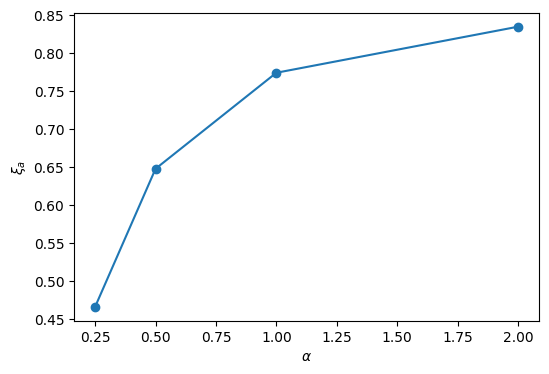

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(xi_a_by_alpha.keys()), list(xi_a_by_alpha.values()), marker="o")
ax.set_xlabel(rf"$\alpha$")
ax.set_ylabel(rf"$\xi_a$")
plt.show()

## 6. Need weights: what `w` does

Everything so far has run with uniform weights, which makes ξ a plain
average of shortfalls. That is an *equality* reading: it treats a hop of
distance as equally bad no matter who is on the far end of it.

The weight vector is what turns the metric into an *equity* measure.
Recall the aggregation step:

$$\xi \;=\; \frac{\sum_i w_i\,(1 - A_i)}{\sum_i w_i}$$

`w[i]` is a claim about how much node *i*'s shortfall should count —
normally standing in for need, vulnerability, or risk. A node with twice
the weight contributes twice as much to the total. Three properties follow
directly from the formula and are worth stating explicitly:

- **Only relative weights matter.** The denominator normalises, so
  multiplying every weight by 100 leaves ξ unchanged. `w` is a profile,
  not a quantity, and you never need to make it sum to anything in
  particular.
- **A zero weight removes a node from the accounting entirely.** Its
  access is still computed, but its shortfall is not counted. That is
  occasionally what you want (a node representing a service rather than a
  person) and is otherwise a strong assumption.
- **`w` never changes `A`.** Weights affect who *counts*, not who *has
  access*. The two questions stay cleanly separated, which is what makes
  the comparison below interpretable.

The important consequence is this: **`G`, `R` and the whole access vector
`A` can be held completely fixed while ξ moves a long way, purely because
of `w`.** Coverage — the share of people served — is blind to that
movement. This is the core claim the metric exists to make.

### 6.1 Need weights on the toy path

Same chain, same holder at node 0, same access scores as before. All that
changes is where we say the need is:

- `w_uniform` — everyone counts equally (the equality baseline).
- `w_near` — the three nodes nearest the holder (0, 1, 2) count three
  times as much as the rest. Need happens to sit where the resource is.
- `w_far` — the three nodes at the far end (4, 5, 6) count three times as
  much. Need sits where the resource is not.

The intervention is identical in all three cases. Only our judgement about
whose exclusion matters has changed.

In [33]:
# Three need-weighting schemes on the *same* network and the *same* R.
w_uniform = {node: 1.0 for node in G.nodes()}                          # equality baseline
w_near = {node: (3.0 if node <= 2 else 1.0) for node in G.nodes()}     # need near the holder
w_far = {node: (3.0 if node >= 4 else 1.0) for node in G.nodes()}      # need at the far end

print(f"{'weights':10s} {'xi_a':>8s} {'xi_d':>8s}")
for name, weights in [("uniform", w_uniform), ("near", w_near), ("far", w_far)]:
    a = xi_a(G, R, w=weights, alpha=1.0)[0]
    d = xi_d(G, R, w=weights, d=2)[0]
    print(f"{name:10s} {a:8.3f} {d:8.3f}")

# Only the *relative* weights matter: scaling every weight by 100 changes nothing.
w_near_scaled = {node: (300.0 if node <= 2 else 100.0) for node in G.nodes()}
print("\nw_near rescaled x100 -> xi_a =", round(xi_a(G, R, w=w_near_scaled, alpha=1.0)[0], 3))

weights        xi_a     xi_d
uniform       0.774    0.571
near          0.647    0.308
far           0.874    0.769

w_near rescaled x100 -> xi_a = 0.647


The spread is substantial, and it comes from nothing but `w`:

| weights | $\xi_a$ | $\xi_d$ |
|---|---|---|
| uniform | 0.774 | 0.571 |
| near | 0.647 | 0.308 |
| far | 0.874 | 0.769 |

Under $\xi_d$ the reading swings from 0.308 to 0.769 — from a fairly
equitable-looking intervention to a badly inequitable one — while the set
of served nodes {0, 1, 2} never changes. An evaluator reporting coverage
would report 3/7 in every row and see nothing at all.

$\xi_a$ moves in the same direction but less dramatically (0.647 to 0.874),
which is a general pattern: because it grades access continuously, no node
is ever fully written off, so reweighting cannot swing it as far as it
swings a metric with a hard boundary. The rescaling check at the bottom
confirms the normalisation — `w_near` and `w_near × 100` return exactly
the same value.

### 6.2 Need weights on a network with real structure

The path graph has no degree variation, so "near the holder" and "far from
the holder" had to be imposed by hand. In a scale-free network the
structure supplies the contrast for us: a few hubs with many ties, a long
tail of nodes with two or three.

We build a 100-node Barabási–Albert network and seed the resource at the
3% highest-degree nodes — the standard degree-targeted intervention. Then
we vary only the need profile:

- **`uniform`** — need is unrelated to network position.
- **`degree`** — need is proportional to degree, so the people who need
  the resource most are the well-connected ones.
- **`inv_degree`** — need is proportional to 1/degree, so need is
  concentrated in the periphery.

The middle scheme is the comfortable case for a hub-seeding strategy: it
puts the resource exactly where the need is. The third is the awkward one,
and it is not a contrived scenario — for many health and social outcomes,
isolation and need genuinely travel together.

In [34]:
SF = nx.barabasi_albert_graph(100, 2, seed=7)
degree = dict(SF.degree())

# Seed the 3% highest-degree nodes, as a degree-targeted intervention would.
k = max(1, int(round(0.03 * SF.number_of_nodes())))
seeds = sorted(degree, key=lambda n: -degree[n])[:k]
R_sf = {node: (1.0 if node in seeds else 0.0) for node in SF.nodes()}

print(f"nodes: {SF.number_of_nodes()}, degree range: {min(degree.values())}-{max(degree.values())}")
print(f"seeded {k} nodes: {seeds} (degrees {[degree[s] for s in seeds]})")

nodes: 100, degree range: 2-16
seeded 3 nodes: [1, 0, 5] (degrees [16, 15, 15])


In [38]:
w_sf = {
    "uniform": {node: 1.0 for node in SF.nodes()},                 # need unrelated to position
    "degree": {node: float(degree[node]) for node in SF.nodes()},  # need at the centre
    "inv_degree": {node: 1.0 / degree[node] for node in SF.nodes()},  # need at the periphery
}

xi_a_sf, xi_d_sf = {}, {}
for name, weights in w_sf.items():
    xi_a_sf[name] = xi_a(SF, R_sf, w=weights, alpha=1.0)[0]
    xi_d_sf[name] = xi_d(SF, R_sf, w=weights, d=2)[0]

# Coverage depends on G and R alone - it cannot see the weights at all.
_, A_sf = xi_d(SF, R_sf, w=w_sf["uniform"], d=2)
coverage = sum(A_sf.values()) / len(A_sf)
print(f"coverage within 2 hops: {coverage:.0%} (identical under all three schemes)\n")

print(rf"{'need weights':13s} {'xi_a':>8s} {'xi_d':>8s}")
for name in w_sf:
    print(f"{name:13s} {xi_a_sf[name]:8.3f} {xi_d_sf[name]:8.3f}")

coverage within 2 hops: 89% (identical under all three schemes)

need weights      xi_a     xi_d
uniform          0.574    0.110
degree           0.475    0.066
inv_degree       0.621    0.139


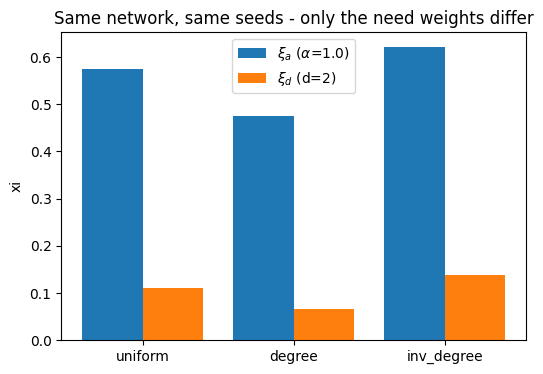

In [39]:
schemes = list(w_sf)
x = np.arange(len(schemes))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.2, [xi_a_sf[s] for s in schemes], width=0.4, label=rf"$\xi_a$ ($\alpha$=1.0)")
ax.bar(x + 0.2, [xi_d_sf[s] for s in schemes], width=0.4, label=rf"$\xi_d$ (d=2)")
ax.set_xticks(x)
ax.set_xticklabels(schemes)
ax.set_ylabel("xi")
ax.set_title("Same network, same seeds - only the need weights differ")
ax.legend()
plt.show()

### Reading the scale-free result

**Coverage says the intervention worked.** 89% of nodes are within two
hops of a seed, from an intervention that touched three nodes. On that
number alone this is a success, and it is the same 89% in every row —
coverage is computed from `G` and `R`, so no choice of weights can move
it.

**ξ says it depends on who was missed.** Under $\xi_d$, inequity roughly
doubles between the centre-weighted and periphery-weighted readings (0.066
to 0.139), with the uniform reading sitting between them at 0.110. $\xi_a$
shows the same ordering on a compressed scale (0.475 / 0.574 / 0.621).
Ordering, not magnitude, is what to read across the two metrics.

**Why it moves in that direction.** The 11 nodes left outside the two-hop
boundary have a mean degree of 2.4, against 4.1 for those inside. Hub
seeding reaches hubs and their neighbours first, so exclusion is
systematically concentrated among low-degree nodes. Weighting by degree
therefore down-weights precisely the people who were missed, and weighting
by inverse degree up-weights them. The same pattern appears in the
continuous access scores: nodes with degree ≤ 2 average `A` = 0.34, while
nodes with degree ≥ 6 average 0.62.

**The general lesson.** Adoption and coverage are *effectiveness*
measures, and they are silent about distribution. A degree-targeted
intervention will nearly always look good on them, because hubs are cheap
to reach and reach many others. Whether it looks good on ξ depends on
something coverage cannot represent: the alignment between where the
resource lands and where the need sits. When those are misaligned — the
`inv_degree` row — the intervention is measurably less equitable at
identical coverage, and only a need-weighted metric will say so.

A caveat on this specific demonstration: the gaps here are real but
modest, because a single 100-node draw with three seeds is a small
example. `degree` and `inv_degree` are also fairly gentle need profiles —
sharper ones (say degree² or a threshold on the bottom quartile) separate
the schemes further. Treat the direction as the finding and the size as an
artefact of the toy setup.

## 7. Takeaways

**On the inputs.** $\xi_a$ and $\xi_d$ share the same inputs (`G`, `R`, `w`). 
`R` is a continuous resource mapping, but for $\xi_d$'s purposes it is read as binary: `R[node] > 0`
means that node holds the resource. Keeping one `R` for both is what makes
the comparison clean.

**On the difference.** $\xi_a$ uses `R`'s magnitude directly as a
distance-discounted quantity (controlled by `alpha`); $\xi_d$ only cares
whether `R` is zero or not, then applies a hard reachability cutoff
(controlled by `d`). Everything else about the two — the shortfall,
the weighting, the aggregation, the [0, 1] scale — is identical.

**On disagreement.** Because of that, $\xi_a$ and $\xi_d$ on the *same* `R`
can disagree in magnitude — that is expected, and reflects the underlying
modelling choice (smooth attenuation vs. hard cutoff), not different data.
Compare them on *patterns across conditions*, not on levels.

**On interpretation.** ξ is a weighted mean of per-node shortfalls, so
it is always decomposable: when a number surprises you, look at the `A`
dict and find the nodes carrying the deficit. A high ξ can mean the
resource is scarce, or that it is badly placed, or that the network is
fragmented — and only the per-node scores tell you which.

**On the weights.** `w` is where the equity claim lives. It changes who
counts, never who has access, and only its relative values matter. Holding
`G`, `R` and `A` fixed and varying `w` alone moved $\xi_d$ from 0.31 to 0.77
on the toy path and roughly doubled it on the scale-free network — all at
constant coverage. That gap is exactly what an effectiveness measure
cannot see.

**What is still missing.** Everything here is a single fixed `R`, not a
diffusion process, and one draw of one network rather than a distribution
over runs. The three topologies behave differently under reweighting —
scale-free networks are far more sensitive to it than random or
small-world ones, because they have the degree heterogeneity for need and
position to become misaligned in the first place — and demonstrating that
properly needs repeated runs rather than the single examples used here.